# Fetching Real Stock Data Using Yahoo Finance

In [6]:
import yfinance as yf
import pandas as pd

# Download AAPL data from 2018 to 2026
data = yf.download('AAPL', start='2018-01-01', end='2025-12-31')
data = data[['Close']]
data.dropna(inplace=True)
print(data.tail())


C:\Users\mar_c\AppData\Local\Temp\ipykernel_5744\906799263.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2018-01-01', end='2025-12-31')
[*********************100%***********************]  1 of 1 completed

Price            Close
Ticker            AAPL
Date                  
2025-12-08  277.890015
2025-12-09  277.179993
2025-12-10  278.779999
2025-12-11  278.029999
2025-12-12  278.279999


# Preprocessing Data for Transformer Input

In [7]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Normalize data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 60
X, y = create_sequences(scaled_data, window_size)

# Reshape to include "features" dimension for Transformer
X = X.reshape((X.shape[0], X.shape[1], 1))
y = y.reshape((y.shape[0], 1))


# Building a Custom Transformer Model in TensorFlow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# ============================================================
# CAPA Time2Vector
# ============================================================
# Esta capa se usa para darle al Transformer noción explícita de tiempo.
# Los Transformers NO entienden el orden temporal por sí solos,
# así que Time2Vector actúa como un "positional encoding aprendible".
class Time2Vector(tf.keras.layers.Layer):

    def __init__(self, seq_len):
        super(Time2Vector, self).__init__()
        # Longitud de la secuencia temporal (ej. 60 días)
        self.seq_len = seq_len

    def build(self, input_shape):
        # ----------------------------
        # PARTE LINEAL DEL TIEMPO
        # ----------------------------
        # Aprende una tendencia temporal lineal
        self.weights_linear = self.add_weight(
            name='weight_linear',
            shape=(self.seq_len,),
            initializer='uniform',
            trainable=True
        )
        self.bias_linear = self.add_weight(
            name='bias_linear',
            shape=(self.seq_len,),
            initializer='uniform',
            trainable=True
        )

        # ----------------------------
        # PARTE PERIÓDICA DEL TIEMPO
        # ----------------------------
        # Aprende patrones cíclicos (ej. ciclos financieros)
        self.weights_periodic = self.add_weight(
            name='weight_periodic',
            shape=(self.seq_len,),
            initializer='uniform',
            trainable=True
        )
        self.bias_periodic = self.add_weight(
            name='bias_periodic',
            shape=(self.seq_len,),
            initializer='uniform',
            trainable=True
        )

    def call(self, x):
        # ----------------------------
        # COMPONENTE LINEAL
        # ----------------------------
        # Captura progresión temporal (tendencia)
        time_linear = self.weights_linear * x + self.bias_linear

        # ----------------------------
        # COMPONENTE PERIÓDICO
        # ----------------------------
        # Captura ciclos repetitivos (seasonality)
        time_periodic = tf.math.sin(
            tf.multiply(x, self.weights_periodic) + self.bias_periodic
        )

        # Se concatenan ambos componentes
        # Resultado: representación temporal enriquecida
        return tf.concat([time_linear, time_periodic], axis=-1)

# ============================================================
# CONSTRUCCIÓN DEL TRANSFORMER
# ============================================================
def build_transformer(seq_len):

    # ----------------------------
    # CAPA DE ENTRADA
    # ----------------------------
    # Input con forma: (timesteps, features)
    input_layer = layers.Input(shape=(seq_len, 1))

    # ----------------------------
    # EMBEDDING TEMPORAL
    # ----------------------------
    # Se añade información explícita del tiempo
    time_embedding = Time2Vector(seq_len)(input_layer)

    # ----------------------------
    # CONCATENACIÓN
    # ----------------------------
    # Se combina la señal original con el embedding temporal
    x = layers.Concatenate()([input_layer, time_embedding])

    # ----------------------------
    # NORMALIZACIÓN
    # ----------------------------
    # Estabiliza el entrenamiento y mejora convergencia
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # ----------------------------
    # SELF-ATTENTION
    # ----------------------------
    # Cada paso temporal "atiende" a los demás
    # num_heads=2 → dos subespacios de atención
    # key_dim=32 → tamaño del espacio de atención
    attention_output = layers.MultiHeadAttention(
        num_heads=2,
        key_dim=32
    )(x, x)

    # ----------------------------
    # SKIP CONNECTION (RESIDUAL)
    # ----------------------------
    # Permite flujo de gradiente y evita degradación
    x = layers.Add()([x, attention_output])

    # ----------------------------
    # NORMALIZACIÓN POST-ATENCIÓN
    # ----------------------------
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # ----------------------------
    # POOLING TEMPORAL
    # ----------------------------
    # Resume toda la secuencia en un solo vector
    # Elimina dimensión temporal
    x = layers.GlobalAveragePooling1D()(x)

    # ----------------------------
    # CAPA DENSA
    # ----------------------------
    # Aprende combinaciones no lineales finales
    x = layers.Dense(64, activation='relu')(x)

    # ----------------------------
    # REGULARIZACIÓN
    # ----------------------------
    x = layers.Dropout(0.1)(x)

    # ----------------------------
    # CAPA DE SALIDA
    # ----------------------------
    # Salida escalar (regresión)
    x = layers.Dense(1)(x)

    # Se construye y retorna el modelo completo
    return tf.keras.Model(inputs=input_layer, outputs=x)


# Training the Transformer Model

In [10]:
import os

# ============================
# CONTROL DE LOGS DE TENSORFLOW
# ============================

# Reduce la verbosidad de logs nativos de TensorFlow (C++)
# 0 = todos, 1 = INFO, 2 = WARNING, 3 = ERROR
# Se usa para evitar spam de mensajes irrelevantes en consola
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf

# Reduce los logs del lado de Python de TensorFlow
# Solo se mostrarán errores críticos
tf.get_logger().setLevel('ERROR')

# ============================
# CONSTRUCCIÓN DEL MODELO
# ============================

# Se construye el Transformer usando la función definida antes
# window_size define cuántos pasos temporales ve el modelo
model = build_transformer(window_size)

# ============================
# COMPILACIÓN DEL MODELO
# ============================

model.compile(
    optimizer='adam',
    # Adam es un optimizador robusto para arquitecturas profundas
    # Ajusta dinámicamente el learning rate

    loss='mse'
    # Mean Squared Error:
    # el modelo intenta minimizar el error cuadrático
    # entre el valor real y el valor predicho
)

# ============================
# RESUMEN DE LA ARQUITECTURA
# ============================

# Muestra:
# - número de capas
# - shapes
# - número de parámetros entrenables
# Sirve para verificar que el Transformer esté bien construido
model.summary()

# ============================
# ENTRENAMIENTO DEL MODELO
# ============================

history = model.fit(
    X,
    y,
    epochs=20,
    # El modelo recorre todo el dataset 20 veces
    # En finanzas, más epochs = más riesgo de overfitting

    batch_size=32,
    # En cada actualización se procesan 32 secuencias
    # Cada secuencia tiene window_size pasos

    validation_split=0.1
    # Usa el 10% final del dataset como validación
    # ⚠️ Riesgo de data leakage si X no está estrictamente ordenado
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vector_1      │ (None, 60, 120)   │        240 │ input_layer_1[0]… │
│ (Time2Vector)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 60, 121)   │          0 │ input_layer_1[0]… │
│ (Concatenate)       │                   │            │ time2_vector_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 121)   │        242 │ concatenate_1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 121)   │     31,289 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 121)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 121)   │        242 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 121)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      7,808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,886 (155.80 KB)

 Trainable params: 39,886 (155.80 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1135 - val_loss: 0.0087
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082 - val_loss: 0.0053
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0043 - val_loss: 0.0072
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0039 - val_loss: 0.0057
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0039 - val_loss: 0.0074
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0039 - val_loss: 0.0063
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037 - val_loss: 0.0070
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0032 - val_loss: 0.0063
Epoch 9/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035 - val_loss: 0.0074
Epoch 10/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0033 - val_loss: 0.0060
Epoch 11/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035 - val_loss: 0.0072
Epoch 12/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0033 - val_l

# Making Predictions and Visualization

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


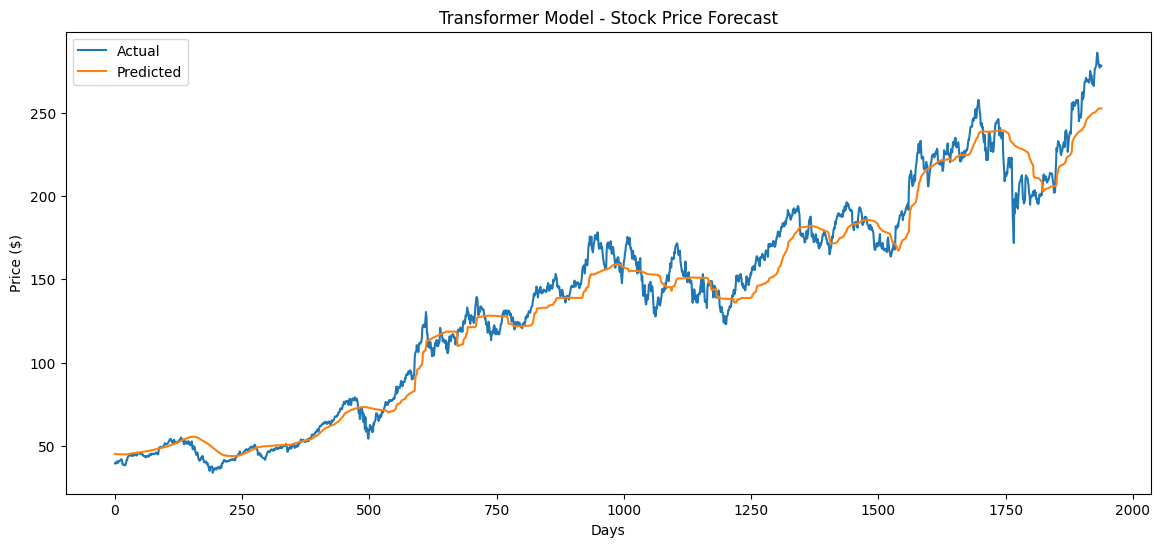

In [5]:
import matplotlib.pyplot as plt

predictions = model.predict(X)
predicted_prices = scaler.inverse_transform(predictions)
real_prices = scaler.inverse_transform(y)

plt.figure(figsize=(14, 6))
plt.plot(real_prices, label='Actual')
plt.plot(predicted_prices, label='Predicted')
plt.title('Transformer Model - Stock Price Forecast')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.show()


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(real_prices, predicted_prices)
rmse = mean_squared_error(real_prices, predicted_prices)

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")


MAE: 8.5899, RMSE: 123.1184


In [13]:
import numpy as np

true_dir = np.sign(np.diff(real_prices.flatten()))
pred_dir = np.sign(np.diff(predicted_prices.flatten()))
dir_acc  = np.mean(true_dir == pred_dir)

print(f"Directional Accuracy: {dir_acc:.3f}")


Directional Accuracy: 0.510


In [14]:
returns = np.diff(real_prices.flatten()) / real_prices[:-1].flatten()
strategy = returns * pred_dir  # long si predice subida, short si bajada

cum_pnl = np.cumsum(strategy)

def sharpe(r):
    return np.mean(r) / np.std(r) * np.sqrt(252)

print(f"Cumulative PnL: {cum_pnl[-1]:.3f}")
print(f"Sharpe: {sharpe(strategy):.2f}")


Cumulative PnL: 0.966
Sharpe: 0.40
